In [1]:
import torch 
import os
import numpy as np
import torch.nn.functional as F

from torch.utils.data import Dataset, random_split
from torch import nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [3]:
# download dataset and split train and test set

cf10_training_data = datasets.CIFAR10(root = 'data', train = True, download= True, transform= transforms.ToTensor()) 

cf10_test_data = datasets.CIFAR10(root = 'Data', train = False, download= True, transform = transforms.ToTensor())


cf100_training_data = datasets.CIFAR100(root = 'data', train = True, download= True, transform= transforms.ToTensor()) 

cf100_test_data = datasets.CIFAR100(root = 'Data', train = False, download= True, transform = transforms.ToTensor())

In [4]:
#Splitting Logic
train_size = 40000
val_size = 10000

# print(len(cf100_training_data))

cf10_train_subset, cf10_val_subset = random_split(cf10_training_data, [train_size,val_size])
#cf100_val_data = random_split(cf100_training_data, [len(cf100_training_data)*0.8, len(cf100_training_data)*0.2])

In [5]:
print(1)
training_loader = torch.utils.data.DataLoader(cf10_train_subset, batch_size=32, shuffle=True)
validation_loader = torch.utils.data.DataLoader(cf10_val_subset, batch_size=32, shuffle=False)
#testing_loader = torch.utils.data.DataLoader(cf10_test_data, batch_size=32, shuffle=False)

1


In [6]:
class LesNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)

        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, (2,2))
        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, (2,2))
        X = X.flatten(1)

        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X
        
model_1 = LesNet().to(device)

In [7]:
# model 2

class Model2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)

        self.fc1 = nn.Linear(5*5*16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

        #add dropuot 
        #self.dropout = nn.Dropout2d(p = 0.3) # 30% chance to be 0

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu') #different relu

    def forward(self, X):
        X = F.relu(self.conv1(X))
        X = F.max_pool2d(X, (2,2))
        X = F.dropout2d(X, p = 0.3)  #add dropuot 

        X = F.relu(self.conv2(X))
        X = F.max_pool2d(X, (2,2))
        X = F.dropout2d(X, p = 0.3)  #add dropuot 
        
        X = X.flatten(1)

        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X

model_2 = Model2().to(device)

In [8]:
# model 3

class Model3(nn.Module): #Batch Normalization
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.bn1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)
        self.bn2 = nn.BatchNorm2d(16)
        

        self.fc1 = nn.Linear(5*5*16, 120)
        self.bn3 = nn.BatchNorm1d(120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

      

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu') #different relu

    def forward(self, X):
        X = F.relu(self.bn1(self.conv1(X)))
        X = F.max_pool2d(X, (2,2))
        

        X = F.relu(self.bn2(self.conv2(X)))
        X = F.max_pool2d(X, (2,2))
       

        X = X.flatten(1)

        X = F.relu(self.bn3(self.fc1(X)))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X

model_3 = Model3().to(device)

In [9]:
#Train for each epoch
def train_one_epoch(model, loader,optimizer, criterion):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for inputs, label in loader:
        if torch.cuda.is_available():
                inputs, label = inputs.cuda(), label.cuda()
                model.cuda()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += label.size(0)
        correct += predicted.eq(label).sum().item()

    average_loss = running_loss / len(loader)
    
    accuracy = correct/ total * 100
    return average_loss, accuracy

In [10]:
#validate each epoch
def validate(model, loader, criterion):
    model.eval() #Set model to eval mode 
    running_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, label in loader:
            if torch.cuda.is_available():
                inputs, label = inputs.cuda(), label.cuda()
                model.cuda()
            outputs = model(inputs)
            loss = criterion(outputs, label)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += label.size(0)
            correct += predicted.eq(label).sum().item()

        average_loss = running_loss / len(loader)
        accuracy = correct/ total * 100
        return average_loss, accuracy

            

In [11]:
def run_full_training_validate(model, train_loader, val_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    history = {"training_loss": [], "training_accuracy": [], "validation_loss": [], "validation_accuracy": []}
    print("---Training and Validation has started---")
    for epoch in range(epochs):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, criterion)
        print(f"Epoch {epoch+1}, Training Loss : {train_loss}, Training Accuracy: {train_accuracy}")
        val_loss, val_accuracy = validate(model, val_loader, criterion)
        print(f"Epoch {epoch+1}, Validation Loss : {val_loss}, Validation Accuracy: {val_accuracy}")

        history['training_loss'].append(train_loss)
        history['training_accuracy'].append(train_accuracy)
        history['validation_loss'].append(val_loss)
        history['validation_accuracy'].append(val_accuracy)

    print('---Training and Validation has ended---')
    return history

In [ ]:
#history_1 = run_full_training_validate(model_1, training_loader, validation_loader)

---Training and Validation has started---
Epoch 1, Training Loss : 1.6079396576881408, Training Accuracy: 40.9075
Epoch 1, Validation Loss : 1.4450785656706593, Validation Accuracy: 47.82
Epoch 2, Training Loss : 1.3488918235778808, Training Accuracy: 51.2425
Epoch 2, Validation Loss : 1.3087268633583484, Validation Accuracy: 52.6
Epoch 3, Training Loss : 1.2458557881832122, Training Accuracy: 55.2275
Epoch 3, Validation Loss : 1.2895433386674704, Validation Accuracy: 54.36
Epoch 4, Training Loss : 1.170887473344803, Training Accuracy: 58.15
Epoch 4, Validation Loss : 1.214681818081548, Validation Accuracy: 56.879999999999995
Epoch 5, Training Loss : 1.106837102127075, Training Accuracy: 60.309999999999995
Epoch 5, Validation Loss : 1.2136386840488202, Validation Accuracy: 57.28
Epoch 6, Training Loss : 1.0523918457508088, Training Accuracy: 62.542500000000004
Epoch 6, Validation Loss : 1.1808836614361966, Validation Accuracy: 58.940000000000005
Epoch 7, Training Loss : 1.0049355748653

In [ ]:
#history_2 = run_full_training_validate(model_2, training_loader, validation_loader)

---Training and Validation has started---
Epoch 1, Training Loss : 1.948505477142334, Training Accuracy: 28.060000000000002
Epoch 1, Validation Loss : 1.819940386869656, Validation Accuracy: 33.96
Epoch 2, Training Loss : 1.7479721090316773, Training Accuracy: 36.3875
Epoch 2, Validation Loss : 1.7361123478069853, Validation Accuracy: 36.5
Epoch 3, Training Loss : 1.6802365394592285, Training Accuracy: 38.982499999999995
Epoch 3, Validation Loss : 1.6728978480774754, Validation Accuracy: 38.72
Epoch 4, Training Loss : 1.6279813882827758, Training Accuracy: 41.192499999999995
Epoch 4, Validation Loss : 1.6405907785549712, Validation Accuracy: 40.25
Epoch 5, Training Loss : 1.5877136974334716, Training Accuracy: 42.370000000000005
Epoch 5, Validation Loss : 1.6099912297611418, Validation Accuracy: 41.52
Epoch 6, Training Loss : 1.5532518642425537, Training Accuracy: 43.86
Epoch 6, Validation Loss : 1.6016536543544488, Validation Accuracy: 42.49
Epoch 7, Training Loss : 1.530749689245224,

In [ ]:
#history_3 = run_full_training_validate(model_3, training_loader, validation_loader)

---Training and Validation has started---
Epoch 1, Training Loss : 1.5849533846378328, Training Accuracy: 42.8425
Epoch 1, Validation Loss : 1.5970607702724469, Validation Accuracy: 42.3
Epoch 2, Training Loss : 1.2963711159229279, Training Accuracy: 53.847500000000004
Epoch 2, Validation Loss : 1.308444370096103, Validation Accuracy: 53.02
Epoch 3, Training Loss : 1.1773993107795715, Training Accuracy: 58.292500000000004
Epoch 3, Validation Loss : 1.2147907351914304, Validation Accuracy: 56.71000000000001
Epoch 4, Training Loss : 1.0932886592388154, Training Accuracy: 61.3775
Epoch 4, Validation Loss : 1.4706475108195418, Validation Accuracy: 49.43
Epoch 5, Training Loss : 1.0284732423305512, Training Accuracy: 63.77
Epoch 5, Validation Loss : 1.0992589790981038, Validation Accuracy: 61.309999999999995
Epoch 6, Training Loss : 0.9664598453760147, Training Accuracy: 65.94
Epoch 6, Validation Loss : 1.083641009018444, Validation Accuracy: 62.03999999999999
Epoch 7, Training Loss : 0.922

In [15]:
# def training_model(model, nr_epochs):
#     criterion = nn.CrossEntropyLoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
#     losses = []
#     for epoch in range(nr_epochs):
#         running_loss = 0

#         for i , data in enumerate(training_loader):
#             inputs, label = data

#             if torch.cuda.is_available():
#                 inputs, label = inputs.cuda(), label.cuda()
#                 model.cuda()

#             else:
#                 model.cpu()

#             optimizer.zero_grad()
#             outputs = model.forward(inputs)
#             loss = criterion(outputs, label)

            

#             loss.backward()
#             optimizer.step()

#             running_loss += loss.item()

           
#         print(f"Epoch {epoch+1}, Loss : {running_loss/len(training_loader)}")


            
# training_model(model_1, 20)

In [24]:
#task 4  Current choice: model3(batch normalization) 
cf100_train_subset, cf100_val_subset = random_split(cf100_training_data, [train_size,val_size])

training_loader_cf100 = torch.utils.data.DataLoader(cf100_train_subset, batch_size=32, shuffle=True)
validation_loader_cf100 = torch.utils.data.DataLoader(cf100_val_subset, batch_size=32, shuffle=False)



100
torch.Size([3, 32, 32])


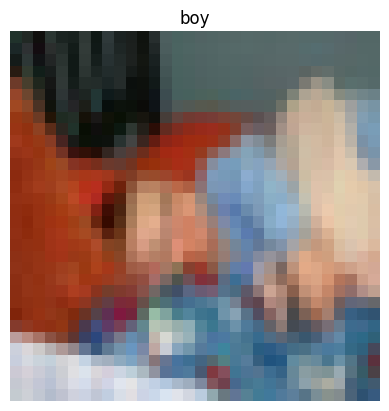

In [25]:
img, label = cf100_train_subset[0]
classes = cf100_training_data.classes
print(len(classes))
print(img.shape)
plt.imshow(img.permute(1,2,0))
plt.title(classes[label])
plt.axis("off")
plt.show()

In [26]:
class Model3_cf100(nn.Module): #it should be cf100 bruh
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.bn1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)
        self.bn2 = nn.BatchNorm2d(16)
        

        self.fc1 = nn.Linear(5*5*16, 120)
        self.bn3 = nn.BatchNorm1d(120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 20)

      

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu') #different relu

    def forward(self, X):
        X = F.relu(self.bn1(self.conv1(X)))
        X = F.max_pool2d(X, (2,2))
        

        X = F.relu(self.bn2(self.conv2(X)))
        X = F.max_pool2d(X, (2,2))
       

        X = X.flatten(1)

        X = F.relu(self.bn3(self.fc1(X)))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X

model_3_cf100 = Model3_cf100().to(device)

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [23]:
history_cf100_1 = run_full_training_validate(model_3_cf100, training_loader_cf100, validation_loader_cf100)

---Training and Validation has started---


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
class Model3_cf100_2(nn.Module): 
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,6,5,1)
        self.bn1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 5, 1)
        self.bn2 = nn.BatchNorm2d(16)
        

        self.fc1 = nn.Linear(5*5*16, 120)
        self.bn3 = nn.BatchNorm1d(120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 20)

      

        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu') #different relu

    def forward(self, X):
        X = F.relu(self.bn1(self.conv1(X)))
        X = F.max_pool2d(X, (2,2))
        

        X = F.relu(self.bn2(self.conv2(X)))
        X = F.max_pool2d(X, (2,2))
       

        X = X.flatten(1)

        X = F.relu(self.bn3(self.fc1(X)))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return X

model_3_cf100 = Model3_cf100_2().to(device)